In [1]:
import os
import glob
import json
import pickle
import datetime
import numpy as np
import matplotlib.pyplot as plt

import scipy as sp
from scipy.interpolate import RegularGridInterpolator

from skimage.feature import canny
from scipy.interpolate import interp1d

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from plot_utils import *
from measure_utils import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
root_dir = "./results/synchron/scene01"
save_str = datetime.datetime(2024, 3, 13)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

results_dir = os.path.join(root_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 50


In [3]:
def upsampling_smooting(orig_response, eval_arrx, eval_arry, y_min, y_max, x_min, x_max,
                         sigma_x = 25, sigma_y = 25,  resolution = 500):

    # Upsampling the response map to 500 points

    high_res_y = np.linspace(y_min, y_max, resolution)
    high_res_x = np.linspace(x_min, x_max, resolution)

    fit_points = [eval_arry, eval_arrx]
    interp = RegularGridInterpolator(fit_points, orig_response, bounds_error = True, fill_value = 0)

    eval_y_high, eval_x_high = np.meshgrid(high_res_y, high_res_x, indexing='ij')

    interp_points = np.array([eval_y_high.ravel(), eval_x_high.ravel()]).T

    response_node_01_high = interp(interp_points, method='slinear').reshape(resolution, resolution)
    # response_node_01_high = lyapunov_threshold(response_node_01_high, 0.000)

    # Smoothing the response map to have continuous boundary by applying gaussian filter
    sigma = [sigma_y, sigma_x]
    smoothed_node_01_high = sp.ndimage.filters.gaussian_filter(response_node_01_high, sigma, mode='nearest')
    # smoothed_node_01_high = lyapunov_threshold(smoothed_node_01_high, 0.000)

    return high_res_y, high_res_x, smoothed_node_01_high

def boundary_detection(response_map, y_arr, x_arr):
    # edge detection using Canny Edge Detector
    edge_coord = canny(response_map)
    y_coord, x_coord = np.where(edge_coord == 1)

    y_edges = y_arr[y_coord]
    x_edges = x_arr[x_coord]

    # sorting the values
    x_order_ind = np.argsort(x_edges)
    x_edges_sort = x_edges[x_order_ind]
    y_edges_sort = y_edges[x_order_ind]

    # interpolating the points to find the boundary
    function = interp1d(x_edges_sort, y_edges_sort, kind = 'nearest', fill_value='extrapolate')
    
    return function, x_edges_sort, y_edges_sort

In [4]:
iValDict = {}
kValDict = {}

for path in file_paths:
    baseName = os.path.basename(path)
    I = float(baseName.split('_')[-1].split('mV')[0])
    K = float(baseName.split('_K_')[-1].split('_')[0])

    if I not in iValDict.keys():
        iValDict[I] = [path]
        kValDict[I] = [K]
    else:
        iValDict[I].append(path)
        kValDict[I].append(K)

In [5]:
sig_min = 2.5; sig_max = 16.5; sig_steps = 20
eval_sigma = sig_min + np.arange(0, sig_steps) / (sig_steps - 1) * (sig_max - sig_min)

k_min = -1; k_max = 1; k_steps = 10
eval_K = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)

In [6]:
# saveRoot = './results/synchron/scene01/exp-2024-3-14'

# os.makedirs(saveRoot, exist_ok=True)

# for I, paths in iValDict.items():
#     Kvals = np.array(kValDict[I])
#     Ksort = np.argsort(Kvals)
#     Kvals = Kvals[Ksort]
#     paths = np.array(paths)[Ksort]

#     AvalanchSync = np.zeros((k_steps, sig_steps))
#     AvalanchEventDist = np.zeros((k_steps, sig_steps))
#     KuramotoOrder = np.zeros((k_steps, sig_steps))
#     nlcor_ = np.zeros((k_steps, sig_steps))
#     distCorr = np.zeros((k_steps, sig_steps))

#     GlobalSync = np.zeros((k_steps, sig_steps))
#     SVDSync = np.zeros((k_steps, sig_steps))
#     MI_phase = np.zeros((k_steps, sig_steps))
#     MI_amp = np.zeros((k_steps, sig_steps))
#     PLVSync = np.zeros((k_steps, sig_steps))

#     synchron_data = {
#                     'Avalanch': AvalanchSync,
#                     'AvalanchDist': AvalanchEventDist,
#                     'Kuramoto': KuramotoOrder,
#                     'GlobalSync': GlobalSync,
#                     'SVD': SVDSync,
#                     'MI_phase': MI_phase,
#                     'MI_amp': MI_amp,
#                     'PLV': PLVSync,
#                     'DistCor': distCorr,
#                     'nlCor': nlcor_

#     }

#     fileName = f"synch_ie_{I:.3f}mv.pkl"
    
#     for nf, path in enumerate(paths):
#         Synchdict = pickle.load(open(path, 'rb'))
        
#         for measure, measureArr in Synchdict.items():
#             try:
#                 synchron_data[measure][nf, :] = np.mean(measureArr, axis=1)
#             except:
#                 print(path, measureArr)
    
#     with open(os.path.join(saveRoot, fileName), 'wb') as file_:
#         pickle.dump(synchron_data, file_)

In [7]:
# read parameters from a json file
with open('./params.json', 'r+') as f:
    params = json.load(f)

# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
n_trials = 10

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

In [8]:
# setting init values
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

In [9]:
t_start = 1000
t_end = params['T']

In [10]:
save_str = datetime.datetime(2024, 3, 14)
results_dict = os.path.join('./results/synchron/scene01', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

file_paths = glob.glob(os.path.join(results_dict, "*.pkl"))
num_files = len(file_paths)
print(num_files)

5


In [12]:
I_vals = []

if num_files == 0:
    print('no files found!')

else:
    for nf, path in enumerate(file_paths):
        basename = os.path.basename(path).split('mv.pkl')[0]
        I = float(basename.split('_ie_')[-1])
        I_vals.append(I)
    
    I_vals = np.array(I_vals)

    order_ind = np.argsort(I_vals)
    I_vals = I_vals[order_ind]
    file_paths = np.array(file_paths)[order_ind]

    colors= plt.get_cmap('Reds')
    colorIter = iter(colors(np.linspace(0.3, 1, len(I_vals))))

    plt.figure(figsize=(10,8))
    counter = 0
    for nf, path in enumerate(file_paths):
        print(f"Running the file for {I_vals[nf]:.3f}mV")
        basename = os.path.basename(path).split('mv.pkl')[0]
        color = next(colorIter)

        synchData = pickle.load(open(path, 'rb'))
        globalSynch = synchData['GlobalSync']

        nanVal = np.argwhere(np.isnan(globalSynch))

        if len(nanVal) != 0:
             print(nanVal.shape)
             for kInd, sigInd in nanVal:
                params['K'] = eval_K[kInd]
                params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = eval_sigma[sigInd]
                params['i_e1'] = I_vals[nf] / params['gamma']

                u = np.zeros((n_trials, 4, T))
                u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

                SSync = SpectrumSynch(time_series=u, tstart=t_start, tend=t_end, fmin=80, fmax=140, fs=1000, window_size=250, step_window=50)
                glob_trial, svd_trial, mi_phase_trial, mi_amp_trial, plv_trial = SSync.calc_synchronization()

                synchData['GlobalSync'][kInd, sigInd] = np.mean(glob_trial)
                synchData['SVD'][kInd, sigInd] = np.mean(svd_trial)
                synchData['MI_phase'][kInd, sigInd] = np.mean(mi_phase_trial)
                synchData['MI_amp'][kInd, sigInd] = np.mean(mi_amp_trial)
                synchData['PLV'][kInd, sigInd] = np.mean(plv_trial)

                print(synchData['GlobalSync'][kInd, sigInd], synchData['SVD'][kInd, sigInd], synchData['MI_phase'][kInd, sigInd], synchData['MI_amp'][kInd, sigInd], synchData['PLV'][kInd, sigInd])

        pickle.dump(synchData, open(path, 'wb'))

Running the file for -15.625mV
Running the file for -6.250mV
Running the file for 0.000mV
Running the file for 6.250mV
Running the file for 15.625mV


<Figure size 1000x800 with 0 Axes>

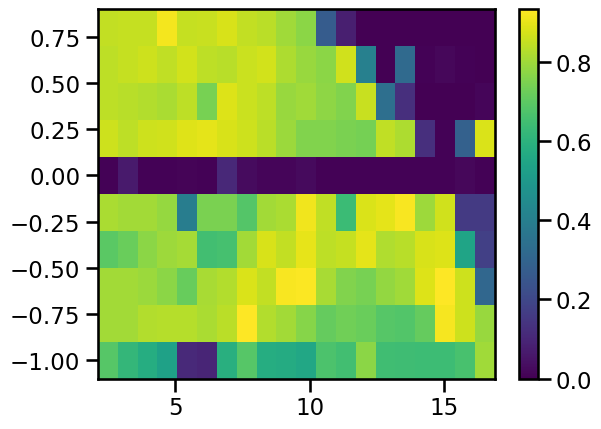

In [21]:
plt.pcolormesh(eval_sigma, eval_K, synchData['SVD'])
plt.colorbar()

In [24]:
a = np.zeros(10)
b = np.zeros(10)
c = b / a

In [25]:
c

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [26]:
d = np.argwhere(np.isnan(c))

In [27]:
c[d] = 0

In [28]:
c

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])